# Étude d'une unité de liquéfaction d'$H_2$

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP
import seaborn as sns
import pandas as pd
sns.set_style("darkgrid")

## Question 1

Text(0.5, 1.0, 'Solubilité de $O_2$ dans $H_2$ en fonction de la température')

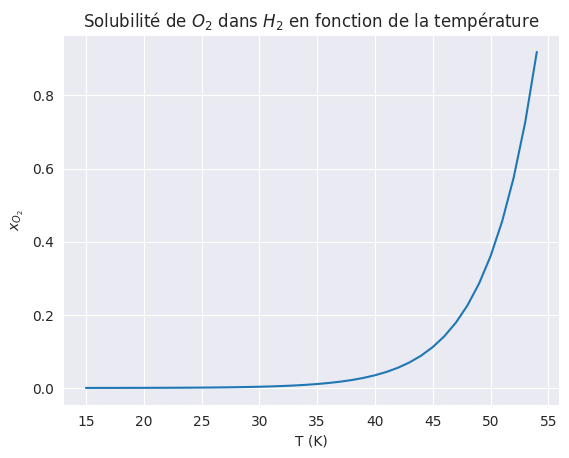

In [17]:
delta_h_1 = 0.445
T1 = 54.361
R = 8.314
T = np.arange(15,55,1) # T va de 15 à 54, pas de 1
A = 334527*np.exp(-0.234*T)
x_O2 = 1/A * np.exp(delta_h_1/R/T1*(1-T1/T))

plt.plot(T,x_O2)
plt.xlabel('T (K)')
plt.ylabel(r'$x_{O_2}$')
plt.title(r"Solubilité de $O_2$ dans $H_2$ en fonction de la température")

Solubilité de $O_2(s)$ à la température finale de liquéfaction de $H_2$ (20.65K)?

In [18]:
Tf = 20.65
A = 334527*np.exp(-0.234*Tf)
x_O2f = 1/A * np.exp(delta_h_1/R/T1*(1-T1/Tf))

print(f"Solubilité de O2 à {Tf} K : {x_O2f}")

Solubilité de O2 à 20.65 K : 0.0003744769759273762


## Question 2

La solubilité de l'oxygène solide est donc de 0.03745%.
Or, en sortie de l'électrolyseur, la fraction molaire de dioxygène résiduel est égale à 1000ppm, soit 0.1%. Cette concentration présente donc un risque de cristallisation à la température finale de liquéfaction de l'H2.
Il y a un rapport 2.67 entre ces deux valeurs, ce qui correspond au taux de purification minimale qui doit être pris en compte pour le design de l'unité de purification.

## Question 3

On considère un système idéal.

Hypothèse : le gaz qui alimente le volume reste entièrement liquéfié.

On applique le premier principe de la thermodynamique entre 1 et 3 :

$$
\dot{m}_{1}\left(h_{3} - h_{1}\right) + \Delta e = \dot{W}_E + \dot{W}_C + \dot{Q}_R \tag{1}
$$

On retire les termes négligeables et on obtient :

$$
\dot{m}_{1}\left(h_{3} - h_{1}\right) = \dot{W}_C + \dot{Q}_R \tag{2}
$$

On applique ensuite le second principe de la thermodynamique entre 1 et 3 :

$$
\dot{m}_{1}\left(s_{3} - s_{1}\right) = \displaystyle\frac{\dot{Q}_R}{T_1} \tag{3}
$$

En injectant (3) dans (2), on obtient :

$$
\displaystyle\frac{\dot{W}_C}{\dot{m}_1} = h_3 - h_1 - T_1\left(s_3 - s_1\right) \tag{4}
$$

## Question 4

In [19]:
T1 = 298.15
P1 = 1.1e5

table = {
    "Oxygen": {},
    "Nitrogen": {},
    "Methane": {},
    "Hydrogen": {}
}


for fluide in table.keys():
    h1 = CP.PropsSI ('H', 'P', P1, 'T', T1, fluide) #on récupère h1(fluide)
    s1 = CP.PropsSI ('S', 'P', P1, 'T', T1, fluide) #on récupère s1(fluide)
    h3 = CP.PropsSI ('H', 'P', P1, 'Q', 0 , fluide) # on récupère l'enthalpie sur la courbe d'ébullition (hyp : le gaz est entièrement liq)
    s3 = CP.PropsSI ('S', 'P', P1, 'Q', 0 , fluide) #on récupère s1(fluide)

    travail = h3 - h1 -T1*(s3-s1)
    table[fluide]["Travail"] = travail

df = pd.DataFrame(table)
df

,Oxygen,Nitrogen,Methane,Hydrogen
Travail,619368.021953,750325.292329,1.061585e+06,1.184431e+07


## Question 5

$$
PCI\left(H_2\right) = 123\ \mathrm{MJ}\cdot\mathrm{kg}^{-1}
$$

D'après la question 4 :

$$
\displaystyle\frac{\dot{W}_{\mathrm{idéal}}}{\dot{m}_1} = 11{,}8\ \mathrm{MJ}\cdot\mathrm{kg}^{-1}
$$

On complète ensuite le reste du tableau :

$$
\displaystyle\frac{\dot{W}_{\mathrm{idéal}}}{PCI} = 100\times\left(\displaystyle\frac{11{,}8}{123}\right) = 9{,}59\ \%
$$

On nous donne :

$$
\displaystyle\frac{\dot{W}_{\mathrm{réel}}}{\dot{m}_1} = 36\ \mathrm{MJ}\cdot\mathrm{kg}^{-1}
$$

Donc :

$$
\displaystyle\frac{\dot{W}_{\mathrm{réel}}}{PCI} = 100\times\left(\displaystyle\frac{36}{123}\right) = 29{,}3\ \%
$$

## Question 6

Cette transformation apporte de l'énergie supplémentaire au système (0,7MJ/kg). On va donc corriger les valeurs de W dans le cas idéal puis réel.

##### CAS IDEAL

$$
W_{idéal,corrigé} = 11,8 + 0,7 = 12,5 \ \mathrm{MJ/kg}
$$

Le travail de liquéfaction augmente donc jusqu'à 12,5MJ/kg.

Calcul de l'impact sur le PCI

$$
impact = W_{idéal,corrigé}/PCI = 12,5/123 \times 100 = 10,2\%
$$

##### CAS REEL

$$
W_{réel,corrigé} = 36 + 0,7 = 36,7 \ \mathrm{MJ/kg}
$$

Le travail de liquéfaction augmente donc jusqu'à 36,7MJ/kg.

Calcul de l'impact sur le PCI

$$
impact = W_{réel,corrigé}/PCI = 36,7/123 \times 100 = 29,9\%
$$

L’augmentation due à la conversion ortho → para vaut :

$$
\Delta\% = \frac{0,7}{123}\times{100} = 0,57\%
$$

Son impact est non négligeable dans le procédé de liquéfaction.


_Remarque_ : Si on veut être plus précis dans l'analyse thermodynamique.  
Cette chaleur est dégagée à très basse température (20.65 K). Son évacuation dans le cas idéal nécessite donc un travail supérieur à 0,7 MJ·kg⁻¹, de l'ordre de 0.7x(298,15-20.65)/20.65 = 9.4 MJ·kg⁻¹ (calculé avec la formule du COP d'une cycle de Carnot) ce qui porterait le travail idéal total à environ 21,2 MJ·kg⁻¹ et l'impact sur le PCI à 17.2%  et $\Delta\% = 5.4 \% $  

## Question 7

Relation différentielle de l'enthalpie :

$$
dh = \left(\displaystyle\frac{\partial h}{\partial T}\right)_P dT + \left(\displaystyle\frac{\partial h}{\partial P}\right)_T dP
$$

Avec les relations de Maxwell :

$dh = Tds + vdP$ et $\left(\displaystyle\frac{\partial s}{\partial P}\right)_T = -\left(\displaystyle\frac{\partial v}{\partial T}\right)_P$.

On en déduit :

$$
\left(\displaystyle\frac{\partial h}{\partial P}\right)_T = v - T\left(\displaystyle\frac{\partial v}{\partial T}\right)_P
$$

En remplaçant dans l'expression de $dh$ :

$$
dh = C_P\,dT + \left(v - T\left(\displaystyle\frac{\partial v}{\partial T}\right)_P\right)dP
$$

Dans le cas isenthalpique, $dh = 0$, donc :

$$
\mu_{JT} = \left(\displaystyle\frac{\partial T}{\partial P}\right)_H = \displaystyle\frac{1}{C_P}\left(T\left(\displaystyle\frac{\partial v}{\partial T}\right)_P - v\right)
$$

Pour un gaz parfait :

$$
pv = \displaystyle\frac{RT}{M} = rT
$$

avec

$$
r = \displaystyle\frac{R}{M}
$$

Donc :

$$
v = \displaystyle\frac{rT}{P}
$$

et

$$
\left(\displaystyle\frac{\partial v}{\partial T}\right)_P = \displaystyle\frac{r}{P}
$$

Ainsi :

$$
\mu_{JT} = 0
$$

Ainsi, dans le cas particulier d'une détente isenthalpique pour un gaz parfait, la chute de pression ne s'accompagne pas d'une modification de la température : le coefficient de Joule-Thomson est nul.

## Question 8

In [20]:
table = {
    "Oxygen": {},
    "Nitrogen": {},
    "Methane": {},
    "Hydrogen": {}
}

P1 = 50e5
T1 = 298.15
P = 1.1e5

for fluide in table.keys():
    h1 = CP.PropsSI('H', 'P', P1, 'T', T1, fluide)
    s1 = CP.PropsSI('S', 'P', P1, 'T', T1, fluide)

    # Détente isenthalpique
    T_f = CP.PropsSI('T', 'P', P, 'H', h1, fluide)
    
    table[fluide]["T_f"] = T_f
    table[fluide]["delta_T"] = T_f - T1

df = pd.DataFrame(table)
df

,Oxygen,Nitrogen,Methane,Hydrogen
T_f,285.140179,288.194081,275.877491,299.680764
delta_T,-13.009821,-9.955919,-22.272509,1.530764


On remarque que $\Delta T < 0$ pour tout les gaz sauf l'hydrogène, ce qui signifie que les gaz se refroidissent lors de la détente, tandis que l'hydrogène se réchauffe. Donc, pour l'hydrogène, la détente isenthalpique ne permet pas de réduire sa température, ce qui rend la liquéfaction plus difficile.

## Question 9

On implémente le tableau avec les données fournies.

In [21]:
table = {
    "A" : {},
    "B" : {},
    "C" : {},
    "D" : {},
    "E" : {},
    "F" : {},
    "G" : {},
    "H" : {},
    "I" : {},
    "J" : {},
    "K" : {},
    "L_rev" : {},
    "L_irrev" : {},
    "M" : {},
    "N" : {},
    "O_rev" : {},
    "O_irrev" : {},
    "P" : {}
}

for point in table.keys():
    table[point]["Débit"] = float
    table[point]["Température"] = float
    table[point]["Pression"] = float
    table[point]["Enthalpie"] = float
    table[point]["Entropie"] = float
    table[point]["Titre"] = float

In [22]:
table["A"]["Débit"] = 100
table["A"]["Température"] = 298.15
table["A"]["Pression"] = 30
table["A"]["Titre"] = 1

table["C"]["Température"] = 110

table["E"]["Température"] = 50

table["G"]["Température"] = 20.65
table["G"]["Pression"] = 1.1
table["G"]["Titre"] = 0.7

table["H"]["Titre"] = 0

table["I"]["Titre"] = 1

Les conservations de la masse autour des mélangeurs et du séparateur s'écrivent :
$$
\begin{cases}
\dot{m}_A + \dot{m}_P = \dot{m}_B\\
\dot{m}_C = \dot{m}_D + \dot{m}_K\\
\dot{m}_G = \dot{m}_H + \dot{m}_I\\
\dot{m}_J + \dot{m}_L = \dot{m}_M
\end{cases}
$$

Les données des taux de fractionnement du points $C$ et de séparation du point $G$ permettent d'écrire :

$$\begin{cases}
\dot{m}_D = \frac{85}{100} \dot{m}_C\\
\dot{m}_I = \frac{70}{100} \dot{m}_G
\end{cases}$$

On peut donc calculer les débits massiques :

In [23]:
table["H"]["Débit"] = table["A"]["Débit"]

table["G"]["Débit"] = table["H"]["Débit"]/(1-table["G"]["Titre"])
table["I"]["Débit"] = table["G"]["Débit"]*(table["G"]["Titre"])

table["J"]["Débit"] = table["I"]["Débit"]

table["F"]["Débit"] = table["E"]["Débit"] = table["D"]["Débit"] = table["G"]["Débit"]

table["C"]["Débit"] = (100/85)*table["D"]["Débit"]
table["B"]["Débit"] = table["C"]["Débit"]

table["P"]["Débit"] = table["B"]["Débit"] - table["A"]["Débit"]

table["O_rev"]["Débit"] = table["O_irrev"]["Débit"] = table["N"]["Débit"] = table["M"]["Débit"] = table["P"]["Débit"]

table["L_rev"]["Débit"] = table["M"]["Débit"] - table["J"]["Débit"]

table["L_irrev"]["Débit"] = table["K"]["Débit"] = table["L_rev"]["Débit"]

On vérifie ensuite la conservation de la masse autour du mélangeur $C$ (l'équation n'ayant pas été utilisée pour le calcul des débits massiques) :

In [24]:
if table["K"]["Débit"] + table["D"]["Débit"] == table["C"]["Débit"] :
    print("Conservation de la masse vérifiée")

Conservation de la masse vérifiée


## Question 10

Outre les multiples égalités d'état sur plusieurs points du cycle, les principales équations à rédiger sont les suivantes :



#### Détente $K \to L_{rev}$ puis $K \to L_{irrev}$ (avec ($\eta=0.75$))

Trajet réversible de référence :
$$s_{L_{rev}}=s_K$$


Travail de référence et travail réel :
$$W_{rev,KL}=h_K-h_{L_{rev}},\qquad W_{reel,KL}=\eta\,W_{rev,KL}.$$


Point réel ($L_{irrev}$) :
$$h_{L_{irrev}}=h_K-W_{reel,KL}$$


#### Mélanges J, M, N


Point J (à partir de E, F et I dans le code) :
$$h_J=\left(\frac{\dot m_E}{\dot m_J}\right)(h_E-h_F)+h_I$$


Point M :
$$h_M=\frac{\dot m_{L_{irrev}}h_{L_{irrev}}+\dot m_J h_J}{\dot m_M},\qquad s_M=\frac{\dot m_{L_{irrev}}s_{L_{irrev}}+\dot m_J s_J}{\dot m_M}$$


Point N :
$$h_N=\left(\frac{\dot m_D}{\dot m_M}\right)(h_D-h_E)+h_M$$


#### Compression $N \to O_{rev}$ puis $N \to O_{irrev}$


Référence réversible vers ($O_{rev}$) :
$$s_{O_{rev}}=s_N$$


Travaux puis point irréversible ($O_{irrev}$) :
$$W_{rev,NO}=h_{O_{rev}}-h_N,\qquad W_{reel,NO}=\frac{W_{rev,NO}}{\eta}$$
$$h_{O_{irrev}}=h_N+W_{reel,NO}$$


In [25]:
table["A"]["Enthalpie"] = CP.PropsSI('H', 'P', table["A"]["Pression"]*1e5,
                                     'T', table["A"]["Température"], 'Hydrogen')/1000
table["A"]["Entropie"] = CP.PropsSI('S', 'P', table["A"]["Pression"]*1e5,
                                    'T', table["A"]["Température"], 'Hydrogen')/1000

for prop in ["Enthalpie", "Entropie", "Température", "Titre", "Pression"]:
    table["B"][prop] = table["P"][prop] = table["A"][prop]

table["G"]["Enthalpie"] = CP.PropsSI('H', 'P', table["G"]["Pression"]*1e5,
                                     'Q', table["G"]["Titre"], 'Hydrogen')/1000
table["G"]["Entropie"] = CP.PropsSI('S', 'P', table["G"]["Pression"]*1e5,
                                     'Q', table["G"]["Titre"], 'Hydrogen')/1000

for point in ["H", "I"]:
    table[point]["Température"] = table["G"]["Température"]
    table[point]["Pression"] = table["G"]["Pression"]

for point in ["H", "I"]:
    table[point]["Enthalpie"] = CP.PropsSI('H', 'T', table[point]["Température"],
                                           'Q', table[point]["Titre"], 'Hydrogen')/1000
    table[point]["Entropie"] = CP.PropsSI('S', 'T', table[point]["Température"],
                                          'Q', table[point]["Titre"], 'Hydrogen')/1000

for point in ["C", "K", "D", "E", "F"]:
    table[point]["Pression"] = table["A"]["Pression"]
    table[point]["Titre"] = table["A"]["Titre"]

for point in ["J", "L_rev", "L_irrev", "M", "N"]:
    table[point]["Pression"] = table["I"]["Pression"]
    table[point]["Titre"] = table["I"]["Titre"]

for prop in ["Pression", "Titre"]:
    table["O_rev"][prop] = table["O_irrev"][prop] = table["P"][prop]

for prop, symbol in zip(["Enthalpie", "Entropie"], ['H', 'S']):
    table["C"][prop] = CP.PropsSI(symbol, 'P', table["C"]["Pression"]*1e5,
                                  'T', table["C"]["Température"], 'Hydrogen')/1000

for point in ["D", "K"]:
    for prop in ["Température", "Enthalpie", "Entropie"]:
        table[point][prop] = table["C"][prop]
    
for prop, symbol in zip(["Enthalpie", "Entropie"], ['H', 'S']):
    table["E"][prop] = CP.PropsSI(symbol, 'P', table["E"]["Pression"]*1e5,
                                  'T', table["E"]["Température"], 'Hydrogen')/1000

eta = 0.75 # Rendement isentropique

# Détente isenthalpique entre F et G
table["F"]["Enthalpie"] = table["G"]["Enthalpie"]
table["F"]["Entropie"] = CP.PropsSI('S', 'P', table["F"]["Pression"]*1e5,
                                  'H', table["F"]["Enthalpie"]*1000, 'Hydrogen')/1000
table["F"]["Température"] = CP.PropsSI('T', 'P', table["F"]["Pression"]*1e5,
                                  'H', table["F"]["Enthalpie"]*1000, 'Hydrogen')

# Détente isentropique entre K et L_rev
table["L_rev"]["Entropie"] = table["K"]["Entropie"]


table["L_rev"]["Température"] = CP.PropsSI('T', 'P', table["L_rev"]["Pression"]*1e5,
                                    'S', table["L_rev"]["Entropie"]*1000, 'Hydrogen')
table["L_rev"]["Enthalpie"] = CP.PropsSI('H', 'P', table["L_rev"]["Pression"]*1e5,
                                    'S', table["L_rev"]["Entropie"]*1000, 'Hydrogen')/1000

# Travail isentropique entre K et L_irrev
W_rev_KL = table["K"]["Enthalpie"] - table["L_rev"]["Enthalpie"]
W_reel_KL = eta * W_rev_KL
table["L_irrev"]["Enthalpie"] = table["K"]["Enthalpie"] - W_reel_KL

table["L_irrev"]["Entropie"] = CP.PropsSI('S', 'P', table["L_irrev"]["Pression"]*1e5,
                                  'H', table["L_irrev"]["Enthalpie"]*1000, 'Hydrogen')/1000
table["L_irrev"]["Température"] = CP.PropsSI('T', 'P', table["L_irrev"]["Pression"]*1e5,
                                  'H', table["L_irrev"]["Enthalpie"]*1000, 'Hydrogen')

table["J"]["Enthalpie"] = (table["E"]["Débit"]/table["J"]["Débit"])*(table["E"]["Enthalpie"] - table["F"]["Enthalpie"]) + table["I"]["Enthalpie"]
table["J"]["Température"] = CP.PropsSI('T', 'P', table["J"]["Pression"]*1e5,
                                  'H', table["J"]["Enthalpie"]*1000, 'Hydrogen')
table["J"]["Entropie"] = CP.PropsSI('S', 'P', table["J"]["Pression"]*1e5,
                                  'H', table["J"]["Enthalpie"]*1000, 'Hydrogen')/1000

table["M"]["Enthalpie"] = (table["L_irrev"]["Débit"]*table["L_irrev"]["Enthalpie"] +
                           table["J"]["Débit"]*table["J"]["Enthalpie"]) / (table["M"]["Débit"])

table["M"]["Entropie"] = (table["L_irrev"]["Débit"]*table["L_irrev"]["Entropie"] +
                           table["J"]["Débit"]*table["J"]["Entropie"]) / (table["M"]["Débit"])

table["M"]["Température"] = CP.PropsSI('T', 'P', table["M"]["Pression"]*1e5,
                                  'H', table["M"]["Enthalpie"]*1000, 'Hydrogen')

table["N"]["Enthalpie"] = (table["D"]["Débit"]/table["M"]["Débit"])*(table["D"]["Enthalpie"] - table["E"]["Enthalpie"]) + table["M"]["Enthalpie"]
table["N"]["Température"] = CP.PropsSI('T', 'P', table["N"]["Pression"]*1e5,
                                  'H', table["N"]["Enthalpie"]*1000, 'Hydrogen')
table["N"]["Entropie"] = CP.PropsSI('S', 'P', table["N"]["Pression"]*1e5,
                                  'H', table["N"]["Enthalpie"]*1000, 'Hydrogen')/1000

table["O_rev"]["Entropie"] = table["N"]["Entropie"]
table["O_rev"]["Température"] = CP.PropsSI('T', 'P', table["O_rev"]["Pression"]*1e5,
                                  'S', table["O_rev"]["Entropie"]*1000, 'Hydrogen')
table["O_rev"]["Enthalpie"] = CP.PropsSI('H', 'P', table["O_rev"]["Pression"]*1e5,
                                  'S', table["O_rev"]["Entropie"]*1000, 'Hydrogen')/1000

# Travail isentropique entre N et O_irrev
W_rev_NO = table["O_rev"]["Enthalpie"] - table["N"]["Enthalpie"]
W_reel_NO = W_rev_NO / eta
table["O_irrev"]["Enthalpie"] = table["N"]["Enthalpie"] + W_reel_NO

table["O_irrev"]["Entropie"] = CP.PropsSI('S', 'P', table["O_irrev"]["Pression"]*1e5,
                                  'H', table["O_irrev"]["Enthalpie"]*1000, 'Hydrogen')/1000
table["O_irrev"]["Température"] = CP.PropsSI('T', 'P', table["O_irrev"]["Pression"]*1e5,
                                  'H', table["O_irrev"]["Enthalpie"]*1000, 'Hydrogen')

In [26]:

# pour l'affichage
df = pd.DataFrame(table)
df = df.transpose()
df

,Débit,Température,Pression,Enthalpie,Entropie,Titre
A,100.000000,298.150000,30.0,3944.547411,39.374458,1.0
B,392.156863,298.150000,30.0,3944.547411,39.374458,1.0
C,392.156863,110.000000,30.0,1385.851084,26.003090,1.0
D,333.333333,110.000000,30.0,1385.851084,26.003090,1.0
E,333.333333,50.000000,30.0,605.965663,15.535221,1.0
F,333.333333,38.708345,30.0,316.005761,8.866171,1.0
G,333.333333,20.650000,1.1,316.005761,15.297586,0.7
H,100.000000,20.650000,1.1,2.849431,0.132958,0.0
I,233.333333,20.650000,1.1,450.211456,21.796979,1.0
J,233.333333,59.167811,1.1,864.439887,33.228162,1.0


## Question 11

In [27]:
dot_W_comp = (table["N"]["Débit"]/3600)*(table["O_irrev"]["Enthalpie"] - table["N"]["Enthalpie"])
W_comp = table["O_irrev"]["Enthalpie"] - table["N"]["Enthalpie"]
print(f"Puissance de compression : {dot_W_comp} kW")
print(f"Travail massique nécessaire à la compression : {W_comp} kJ/kg")

# signe - pour la détente car c'est une énergie récupérée, on prend la valeur absolue
dot_W_det = -(table["K"]["Débit"]/3600)*(table["L_irrev"]["Enthalpie"] - table["K"]["Enthalpie"])
W_det = -(table["L_irrev"]["Enthalpie"] - table["K"]["Enthalpie"])
print(f"Puissance de détente : {dot_W_det} kW")
print(f"Travail massique récupéré par la détente : {W_det} kJ/kg")


dot_Q_1 = -((table["B"]["Débit"]/3600)*(table["C"]["Enthalpie"] - table["B"]["Enthalpie"])
            + table["P"]["Débit"]/3600*(table["P"]["Enthalpie"] - table["O_irrev"]["Enthalpie"]))
dot_Q_2 = -(table["D"]["Débit"]/3600)*(table["E"]["Enthalpie"] - table["D"]["Enthalpie"])
dot_Q_3 = -(table["E"]["Débit"]/3600)*(table["F"]["Enthalpie"] - table["E"]["Enthalpie"])
print(f"Quantité de chaleur à prélever dans l'échangeur D : {dot_Q_2} kW")
print(f"Quantité de chaleur à prélever dans l'échangeur E : {dot_Q_3} kW")
print(f"Quantité de chaleur à prélever dans l'échangeur F : {dot_Q_1} kW")


total_power = dot_W_comp - dot_W_det + dot_Q_1
total_energy = total_power/(table["H"]["Débit"]/3600)
print(f"Énergie consommée par kg d'hydrogène produit : {total_energy} kJ/kg")

PCI_H2 = 123e3
print(f"PCI de l'hydrogène : {PCI_H2} kJ/kg")

print(f"Rapport PCI/Énergie consommée : {PCI_H2 / total_energy}")

Puissance de compression : 352.51114158232394 kW
Travail massique nécessaire à la compression : 4343.694335202328 kJ/kg
Puissance de détente : 10.181186105169523 kW
Travail massique récupéré par la détente : 623.0885896363749 kJ/kg
Quantité de chaleur à prélever dans l'échangeur D : 72.21161303122744 kW
Quantité de chaleur à prélever dans l'échangeur E : 26.848139054551343 kW
Quantité de chaleur à prélever dans l'échangeur F : 451.8212963324959 kW
Énergie consommée par kg d'hydrogène produit : 28589.445065147414 kJ/kg
PCI de l'hydrogène : 123000.0 kJ/kg
Rapport PCI/Énergie consommée : 4.302287075517455


Remarque : les échanges dans EC 2 et 3 sont nuls au global car les fluides chauds et froids font partie du même cycle, ce qui signifie que la chaleur prélevée par les fluides froids est exactement égale à la chaleur cédée par les fluides chauds.
L'énergie consommée par kg d'hydrogène produit est calculée en prenant en compte les puissances de compression et de détente, ainsi que la chaleur prélevée dans l'échangeur EC1. Le PCI de l'hydrogène est supérieur à l'énergie consommée, ce qui indique que le processus de liquéfaction est énergétiquement favorable. En effet :

$$PCI>4\times E_{consommée}$$

## Question 12

In [28]:
T_a = 298.15
T_elv_H2 = CP.PropsSI('T', 'Q', 0, 'P', 1.1e5, 'Hydrogen')  # Température d'ébullition de l'H2 à 1.1 bar
rho_L_H2 = CP.PropsSI('D', 'T', T_elv_H2, 'Q', 0, 'Hydrogen')  # Densité de l'H2 liquide à T_elv_H2
delta_H_H2 = CP.PropsSI('H', 'T', T_elv_H2, 'Q', 0, 'Hydrogen') - CP.PropsSI('H', 'T', T_elv_H2, 'Q', 1, 'Hydrogen')  # Enthalpie de vaporisation de l'H2 à T_elv_H2

results = {
    "O2" : {},
    "N2" : {},
    "CH4" : {},
    "H2" : {} 
}

def compute_e_ratio_fluide(T_elv, rho_L, delta_H):
    return ((T_a - T_elv)/(T_a - T_elv_H2))*((delta_H_H2*rho_L_H2)/(delta_H*rho_L))


for gaz in results.keys() :
    T_elv = CP.PropsSI('T', 'Q', 0, 'P', 1.1e5, gaz)  # Température d'ébullition du gaz à 1.1 bar
    rho_L = CP.PropsSI('D', 'T', T_elv, 'Q', 0, gaz)  # Masse volumique du gaz liquide à T_elv
    delta_H = CP.PropsSI('H', 'T', T_elv, 'Q', 0, gaz) - CP.PropsSI('H', 'T', T_elv, 'Q', 1, gaz)  # Enthalpie de vaporisation du gaz à T_elv

    e_ratio = compute_e_ratio_fluide(T_elv, rho_L, delta_H)

    results[gaz] = {"T_elv" : T_elv,
                    "Rho L" : rho_L,
                    "Delta H" : delta_H,
                    "e_H2/e_fluide" : e_ratio}

df = pd.DataFrame(results)
df

,O2,N2,CH4,H2
T_elv,90.980889,78.058723,112.674137,20.650434
Rho L,1137.225370,802.880036,420.882642,70.524504
Delta H,-212276.554476,-198262.357941,-508976.381093,-447359.853035
e_H2/e_fluide,0.097569,0.157198,0.098438,1.000000


En étudiant les différents résultats, on remarque que l'$H_2$ est le gaz qui génère le moins de BOG. Cela est du en partie au fait que sa température de liquéfaction est plus basse que les autres gaz, ce qui limite la quantité de gaz qui peut se vaporiser à la température ambiante. De plus, l'hydrogène a une faible densité et une faible énergie de vaporisation, ce qui contribue également à réduire le BOG généré lors de sa liquéfaction.

## Conclusion

Cette étude met en évidence les enjeux énergétiques de la liquéfaction de l’hydrogène. Au-delà de l’intérêt théorique, ces résultats peuvent servir à dimensionner des chaînes de production et de stockage pour des applications industrielles comme l’approvisionnement de sites de forte consommation, le transport d’hydrogène sur longue distance ou encore les usages liés à la mobilité lourde et à l’export.